In [1]:
import pandas as pd 
df = pd.read_csv('/Users/samholmes/Desktop/knot_polys.csv')


df = df[['name','alexander_polynomial_vector','jones_polynomial_vector']]
#drop the second row and the first column
df = df.drop(0)


df.head()

import ast

def parse_knot_vector(vector_str):
    if pd.isna(vector_str):
        return []
    standard_list_str = str(vector_str).replace("{", "[").replace("}", "]")
    return ast.literal_eval(standard_list_str)

df["alexander_polynomial_vector"] = df[
    "alexander_polynomial_vector"
].apply(parse_knot_vector)
df["jones_polynomial_vector"] = df["jones_polynomial_vector"].apply(
    parse_knot_vector
)

max_alex_len = df["alexander_polynomial_vector"].apply(len).max()
max_jones_len = df["jones_polynomial_vector"].apply(len).max()

def pad_vector(vector, target_len):
    return vector + [0] * (target_len - len(vector))

df["alexander_polynomial_vector"] = df[
    "alexander_polynomial_vector"
].apply(lambda x: pad_vector(x, max_alex_len))
df["jones_polynomial_vector"] = df["jones_polynomial_vector"].apply(
    lambda x: pad_vector(x, max_jones_len)
)

print(df.head())


  name                alexander_polynomial_vector  \
1  3_1   [0, 2, 1, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0]   
2  4_1   [0, 2, 1, -3, 1, 0, 0, 0, 0, 0, 0, 0, 0]   
3  5_1  [0, 4, 1, -1, 1, -1, 1, 0, 0, 0, 0, 0, 0]   
4  5_2   [0, 2, 2, -3, 2, 0, 0, 0, 0, 0, 0, 0, 0]   
5  6_1   [0, 2, 2, -5, 2, 0, 0, 0, 0, 0, 0, 0, 0]   

                             jones_polynomial_vector  
1     [1, 4, 1, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  
2   [-2, 2, 1, -1, 1, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0]  
3    [2, 7, 1, 0, 1, -1, 1, -1, 0, 0, 0, 0, 0, 0, 0]  
4   [1, 6, 1, -1, 2, -1, 1, -1, 0, 0, 0, 0, 0, 0, 0]  
5  [-2, 4, 1, -1, 2, -2, 1, -1, 1, 0, 0, 0, 0, 0, 0]  


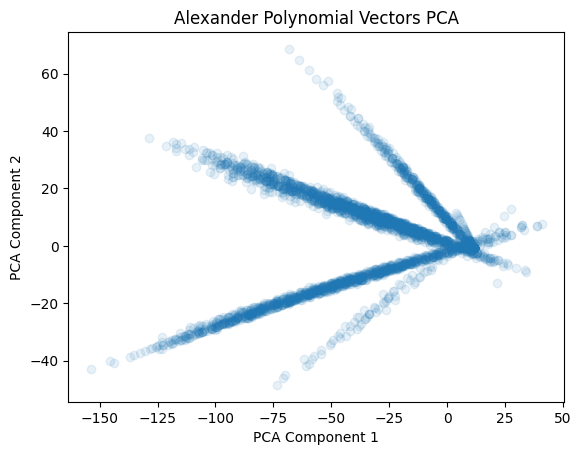

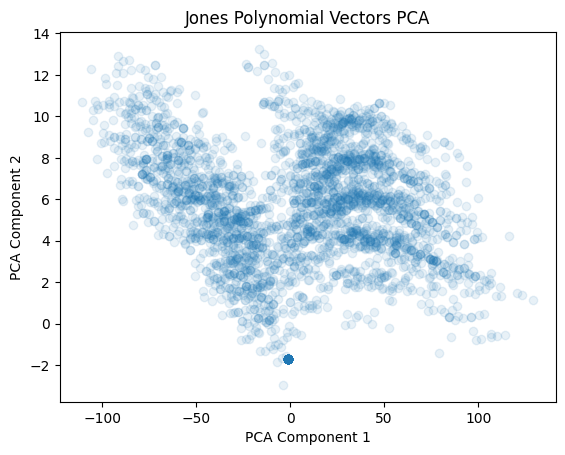

In [22]:
#plot the alexander polynomial vectors as a dimensionality reduction problem using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

alexander_vectors = df["alexander_polynomial_vector"].tolist()
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(alexander_vectors)

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1],alpha=0.1)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Alexander Polynomial Vectors PCA")
plt.show()

#plot the alexander polynomial vectors as a dimensionality reduction problem using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

alexander_vectors = df["jones_polynomial_vector"].tolist()
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(alexander_vectors)

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1],alpha=0.1)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Jones Polynomial Vectors PCA")
plt.show()



In [23]:
"""
Created on Tue Dec 10, 2024

@author: meganfairchild

This script is for MAPPER: dimension reduction and clustering analysis. 
"""

import kmapper as km
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#from kepler_mapper import KeplerMapper
import networkx as nx
import matplotlib.pyplot as plt 
from scipy.spatial.distance import pdist, squareform


def construct_mapper_graph_3D(data_array, num_intervals, overlap_frac):

    """
    Constructs a Mapper graph for the given data using dimension reduction and clustering.
    
    Parameters:
    - data_array: numpy array of data points.
    - num_intervals: Number of intervals to divide the range of the filter function.
    - overlap_frac: Fractional overlap between consecutive intervals.
    """

    try:
        if data_array.size == 0:
            raise ValueError("Input data array is empty.")
        
        # Initialize
        mapper = km.KeplerMapper(verbose=1)
        
        # Step 1: Dimension reduction using PCA and DB scan
        pca = PCA(n_components=3)  # Reduce the data to 3 principal components.
        reduced_data = pca.fit_transform(data_array)  # Apply PCA on the input data.
        
        """
        original_distances = squareform(pdist(data_array))  # Distances in original space
        pca_distances = squareform(pdist(reduced_data))  # Distances in PCA space     
        print(f"Original distance range: {original_distances.min()} to {original_distances.max()}")
        print(f"PCA distance range: {pca_distances.min()} to {pca_distances.max()}")

        I was concerned with the distances used in the Vietoris Rips compared to the mapper clustering for consistency issues. 
        The output from the print with eps=30, min_samples=10, num_intervals= 20, overlap_frac = 0.3 
        AND VR parameters: max_dimension = 2, max_edge_length = 2.0
        resulted in the following: 
        Original distance range: 0.0 to 20.553035938833688
        PCA distance range: 0.0 to 20.313857718359444
        """
        
        dbscan = DBSCAN(eps=30, min_samples=10) #epsilon is distance between points, min_samples is the minimum number of points required to form a dense region 
        #(i.e., a cluster). A point is considered "core" if it has at least min_samples points (including itself) within its eps-radius.
        clusters = dbscan.fit_predict(reduced_data)

        
        # Step 2: Apply Mapper algorithm
        #mapper = Mapper()  # Initialize the Mapper object from scikit-tda.
        #projected_data = mapper.fit_transform(data_array, projection=[0,1]) # X-Y axis
        
        # Create a cover with 10 elements
        #cover = km.Cover(n_cubes=10)
        cover = km.Cover(n_cubes=num_intervals, perc_overlap=overlap_frac)


        # Create dictionary called 'graph' with nodes, edges and meta-information
        graph = mapper.map(reduced_data, cover=cover)

        # Visualize it
        mapper.visualize(graph, path_html="3D_output_cdc_west.html", title="3D_output_cdc_west")

        """
        # Configure the Mapper with necessary parameters:
        graph = mapper.fit_transform(reduced_data, 
                                     cover_params={'num_intervals': num_intervals, 'overlap_frac': overlap_frac}, 
                                     clustering_method=DBSCAN(eps=0.5))
        
        #Step 3: Visualize the Mapper graph
        plt.figure(figsize=(10, 10))  # Set the figure size for the plot.
        nx.draw_networkx(graph, node_size=30, with_labels=False)  # Draw the Mapper graph.
        plt.savefig(output_file)  # Save the graph to the specified output file.
        print(f"Mapper graph saved as {output_file}")  # Inform the user about the saved file.
        """
    except Exception as e:
        print(f"An error occurred: {e}")  # Print any error that occurs.
        raise  # Raise the exception to indicate an error.
        
        

def construct_mapper_graph_2D(data_array, num_intervals, overlap_frac):

    """
    Constructs a Mapper graph for the given data using dimension reduction and clustering.
    
    Parameters:
    - data_array: numpy array of data points.
    - num_intervals: Number of intervals to divide the range of the filter function.
    - overlap_frac: Fractional overlap between consecutive intervals.
    """

    try:
        if data_array.size == 0:
            raise ValueError("Input data array is empty.")
        
        # Initialize
        mapper = km.KeplerMapper(verbose=1)
        
        # Step 1: Dimension reduction using PCA and DB scan
        pca = PCA(n_components=2)  # Reduce the data to 2 principal components.
        reduced_data = pca.fit_transform(data_array)  # Apply PCA on the input data.
        
        dbscan = DBSCAN(eps=30, min_samples=10) #epsilon is distance between points, min_samples is the minimum number of points required to form a dense region 
        #(i.e., a cluster). A point is considered "core" if it has at least min_samples points (including itself) within its eps-radius.
        clusters = dbscan.fit_predict(reduced_data)

        
        # Step 2: Apply Mapper algorithm
        #mapper = Mapper()  # Initialize the Mapper object from scikit-tda.
        #projected_data = mapper.fit_transform(data_array, projection=[0,1]) # X-Y axis
        
        # Create a cover with 10 elements
        #cover = km.Cover(n_cubes=10)
        cover = km.Cover(n_cubes=num_intervals, perc_overlap=overlap_frac)


        # Create dictionary called 'graph' with nodes, edges and meta-information
        graph = mapper.map(reduced_data, cover=cover)

        # Visualize it
        mapper.visualize(graph, path_html="2D_output_cdc_west.html", title="2D_output_cdc_west")

    except Exception as e:
        print(f"An error occurred: {e}")  # Print any error that occurs.
        raise  # Raise the exception to indicate an error.        

--- Running Skeletal TDA Pipeline ---
KeplerMapper(verbose=1)


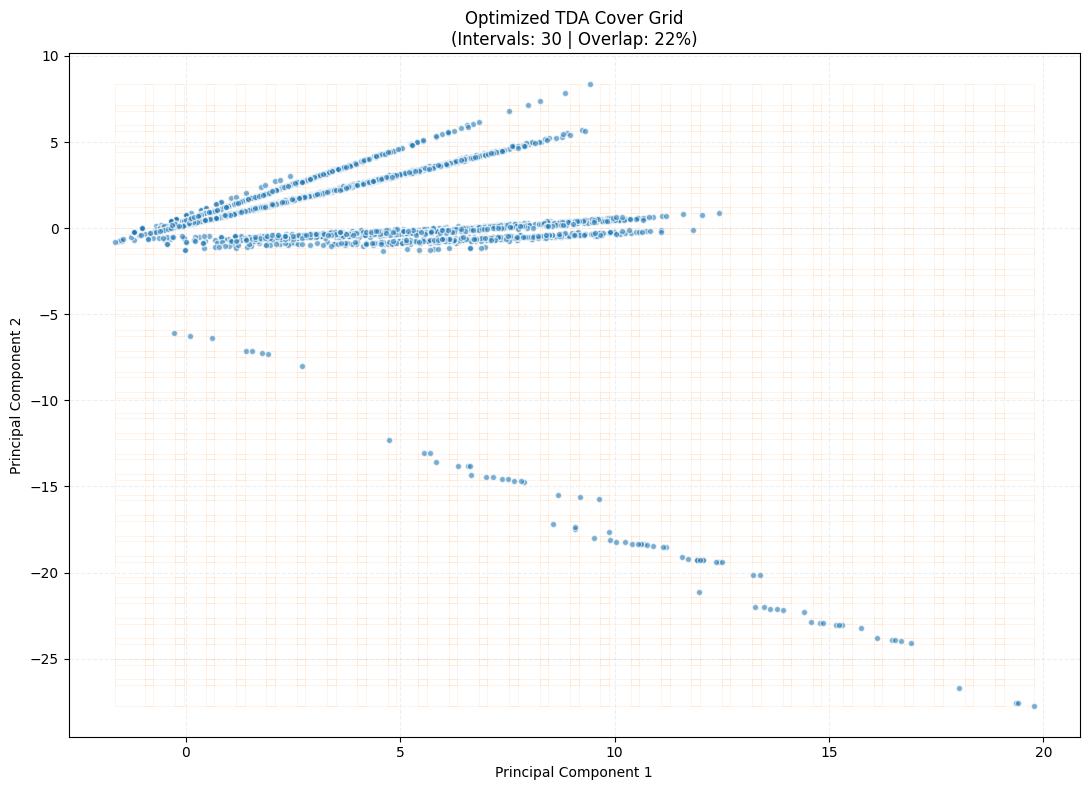

Mapping on data shaped (12965, 2) using lens shaped (12965, 2)

Creating 900 hypercubes.

Created 141 edges and 97 nodes in 0:00:02.543601.
Wrote visualization to: 2D_tree_structure_output.html
--> Successfully saved skeletal tree graph to: 2D_tree_structure_output.html


In [25]:
import kmapper as km
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Convert the column of padded lists into a clean NumPy matrix
alexander_matrix = np.array(df["alexander_polynomial_vector"].tolist())


def visualize_tuning_grid(reduced_data, num_intervals, overlap_frac):
    """Plots the 2D PCA dimensionality reduction and overlays the TDA cover grid."""
    plt.figure(figsize=(11, 8))

    plt.scatter(
        reduced_data[:, 0],
        reduced_data[:, 1],
        c="#1f77b4",
        alpha=0.6,
        edgecolors="w",
        s=20,
        label="Data Points (PCA)",
        zorder=2,
    )

    x_min, x_max = reduced_data[:, 0].min(), reduced_data[:, 0].max()
    y_min, y_max = reduced_data[:, 1].min(), reduced_data[:, 1].max()
    x_range, y_range = x_max - x_min, y_max - y_min

    denom = num_intervals - (num_intervals - 1) * overlap_frac
    x_len = x_range / denom if denom != 0 else x_range
    y_len = y_range / denom if denom != 0 else y_range

    x_step = x_len * (1 - overlap_frac)
    y_step = y_len * (1 - overlap_frac)

    ax = plt.gca()
    for i in range(num_intervals):
        for j in range(num_intervals):
            x_start = x_min + i * x_step
            y_start = y_min + j * y_step
            rect = patches.Rectangle(
                (x_start, y_start),
                x_len,
                y_len,
                linewidth=0.4,
                edgecolor="#ff7f0e",
                fill=False,
                alpha=0.15,
                zorder=1,
            )
            ax.add_patch(rect)

    plt.title(
        f"Optimized TDA Cover Grid\n(Intervals: {num_intervals} | Overlap: {int(overlap_frac*100)}%)"
    )
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle="--", alpha=0.2)
    plt.tight_layout()
    plt.show()


def construct_tree_mapper_graph(data_array, num_intervals, overlap_frac):
    """Extracts the clean skeletal tree/filament structure from the data."""
    try:
        mapper = km.KeplerMapper(verbose=1)

        # Step 1: Pre-scale data so clustering defaults are stable, then run PCA
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(data_array)

        pca = PCA(n_components=2)
        reduced_data = pca.fit_transform(scaled_data)

        # Step 2: View our new high-resolution grid
        visualize_tuning_grid(reduced_data, num_intervals, overlap_frac)

        # Step 3: Set up high-resolution cover
        cover = km.Cover(n_cubes=num_intervals, perc_overlap=overlap_frac)

        # Step 4: Use an explicit DBSCAN clusterer calibrated for scaled space
        # eps=0.35 works beautifully on standard-scaled filament data
        custom_clusterer = DBSCAN(eps=0.35, min_samples=3)

        # Step 5: Map the graph using the tuned clusterer
        graph = mapper.map(
            reduced_data, cover=cover, clusterer=custom_clusterer
        )

        # Step 6: Save the skeletal graph
        output_file = "2D_tree_structure_output.html"
        mapper.visualize(
            graph, path_html=output_file, title="2D Knot Polynomial Tree Structure"
        )
        print(f"--> Successfully saved skeletal tree graph to: {output_file}")

    except Exception as e:
        print(f"An error occurred: {e}")
        raise


# --- RUN WITH SKELETAL TUNING PARAMETERS ---
# 40 intervals ensure the boxes are thin ribbons isolating individual branches.
# 22% overlap allows them to connect cleanly end-to-end without short-circuiting across gaps.
intervals = 30
overlap = 0.22

print("--- Running Skeletal TDA Pipeline ---")
construct_tree_mapper_graph(
    alexander_matrix, num_intervals=intervals, overlap_frac=overlap
)

In [28]:
import numpy as np
import plotly.graph_objects as go
import umap
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Convert the column of padded lists into a clean NumPy matrix
alexander_matrix = np.array(df["alexander_polynomial_vector"].tolist())

# 2. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(alexander_matrix)

# 3. Compute 3D PCA
print("Computing 3D PCA...")
pca = PCA(n_components=3)
pca_3d = pca.fit_transform(scaled_data)

# 4. Compute 3D UMAP
print("Computing 3D UMAP...")
reducer = umap.UMAP(
    n_neighbors=30, min_dist=0.1, n_components=3, random_state=42
)
umap_3d = reducer.fit_transform(scaled_data)

# 5. Create interactive side-by-side 3D subplots with Plotly
fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("3D PCA Projection", "3D UMAP Projection"),
)

# --- Left Plot: 3D PCA ---
fig.add_trace(
    go.Scatter3d(
        x=pca_3d[:, 0],
        y=pca_3d[:, 1],
        z=pca_3d[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=pca_3d[:, 2],  # Color by Z-depth
            colorscale="Viridis",
            opacity=0.6,
        ),
        name="PCA",
    ),
    row=1,
    col=1,
)

# --- Right Plot: 3D UMAP ---
fig.add_trace(
    go.Scatter3d(
        x=umap_3d[:, 0],
        y=umap_3d[:, 1],
        z=umap_3d[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=umap_3d[:, 2],  # Color by Z-depth
            colorscale="Plasma",
            opacity=0.6,
        ),
        name="UMAP",
    ),
    row=1,
    col=2,
)

# 6. Update axes formatting and dimensions
fig.update_layout(
    title_text="Interactive 3D Manifold Projections (PCA vs UMAP)",
    title_font=dict(size=18, family="Arial"),
    width=1400,
    height=700,
    showlegend=False,
)

# Update scene labels for PCA
fig.update_scenes(
    xaxis_title="PC 1",
    yaxis_title="PC 2",
    zaxis_title="PC 3",
    row=1,
    col=1,
)

# Update scene labels for UMAP
fig.update_scenes(
    xaxis_title="UMAP 1",
    yaxis_title="UMAP 2",
    zaxis_title="UMAP 3",
    row=1,
    col=2,
)

# 7. Save and show
output_html = "3d_manifold_projections.html"
fig.write_html(output_html)
fig.show()

print(f"--> Interactive dashboard saved to: {output_html}")

ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.